In [25]:
import os
import urllib.request
import random
import zipfile
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
def download_dataset(dir: str, n: int = 5000):
    """
    Downloads the COCO 2017 validation dataset and selects `n` images from it.
    
    Args:
        dir (str): The path to the folder where data should be downloaded.
        n (int): Number of images to select. Defaults to 5000.
    """
    os.makedirs(dir, exist_ok=True)
    
    coco_val_url = "http://images.cocodataset.org/zips/val2017.zip"
    zip_path = os.path.join(dir, "val2017.zip")
    extract_dir = os.path.join(dir, "val2017")

    if not os.path.exists(extract_dir):
        if not os.path.exists(zip_path):
            print("Downloading COCO val2017 dataset...")
            urllib.request.urlretrieve(coco_val_url, zip_path)
            print("Download completed.")
        
        print("Extracting images...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(dir)
        print("Extraction completed.")
        
        if os.path.exists(zip_path):
            os.remove(zip_path)
    else:
        print("Directory already exists. Skipping download and extraction.")

    image_files = sorted([f for f in os.listdir(extract_dir) if f.endswith('.jpg')])
    selected_images = image_files[:n]
    
    print(f"Success! {len(selected_images)} images saved in: {os.path.abspath(extract_dir)}")

def plot_images(dir: str, n: int = 30):
    """
    Displays `n` random images from the specified directory in a grid.
    
    Args:
        dir (str): Directory containing the images.
        n (int): Number of images to display. Defaults to 30.
    """
    if not os.path.exists(dir):
        print(f"Directory {dir} does not exist.")
        return

    all_images = [f for f in os.listdir(dir) if f.endswith('.jpg')]
    if not all_images:
        print(f"No JPG images found in {dir}.")
        return

    n = min(n, len(all_images))
    selected_images = random.sample(all_images, n)
    
    cols = 5
    rows = (n + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()
    
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(dir, img_name)
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

Directory already exists. Skipping download and extraction.
Success! 5000 images saved in: c:\Users\david\Desktop\DeepImageWatermarking\data\raw\val2017


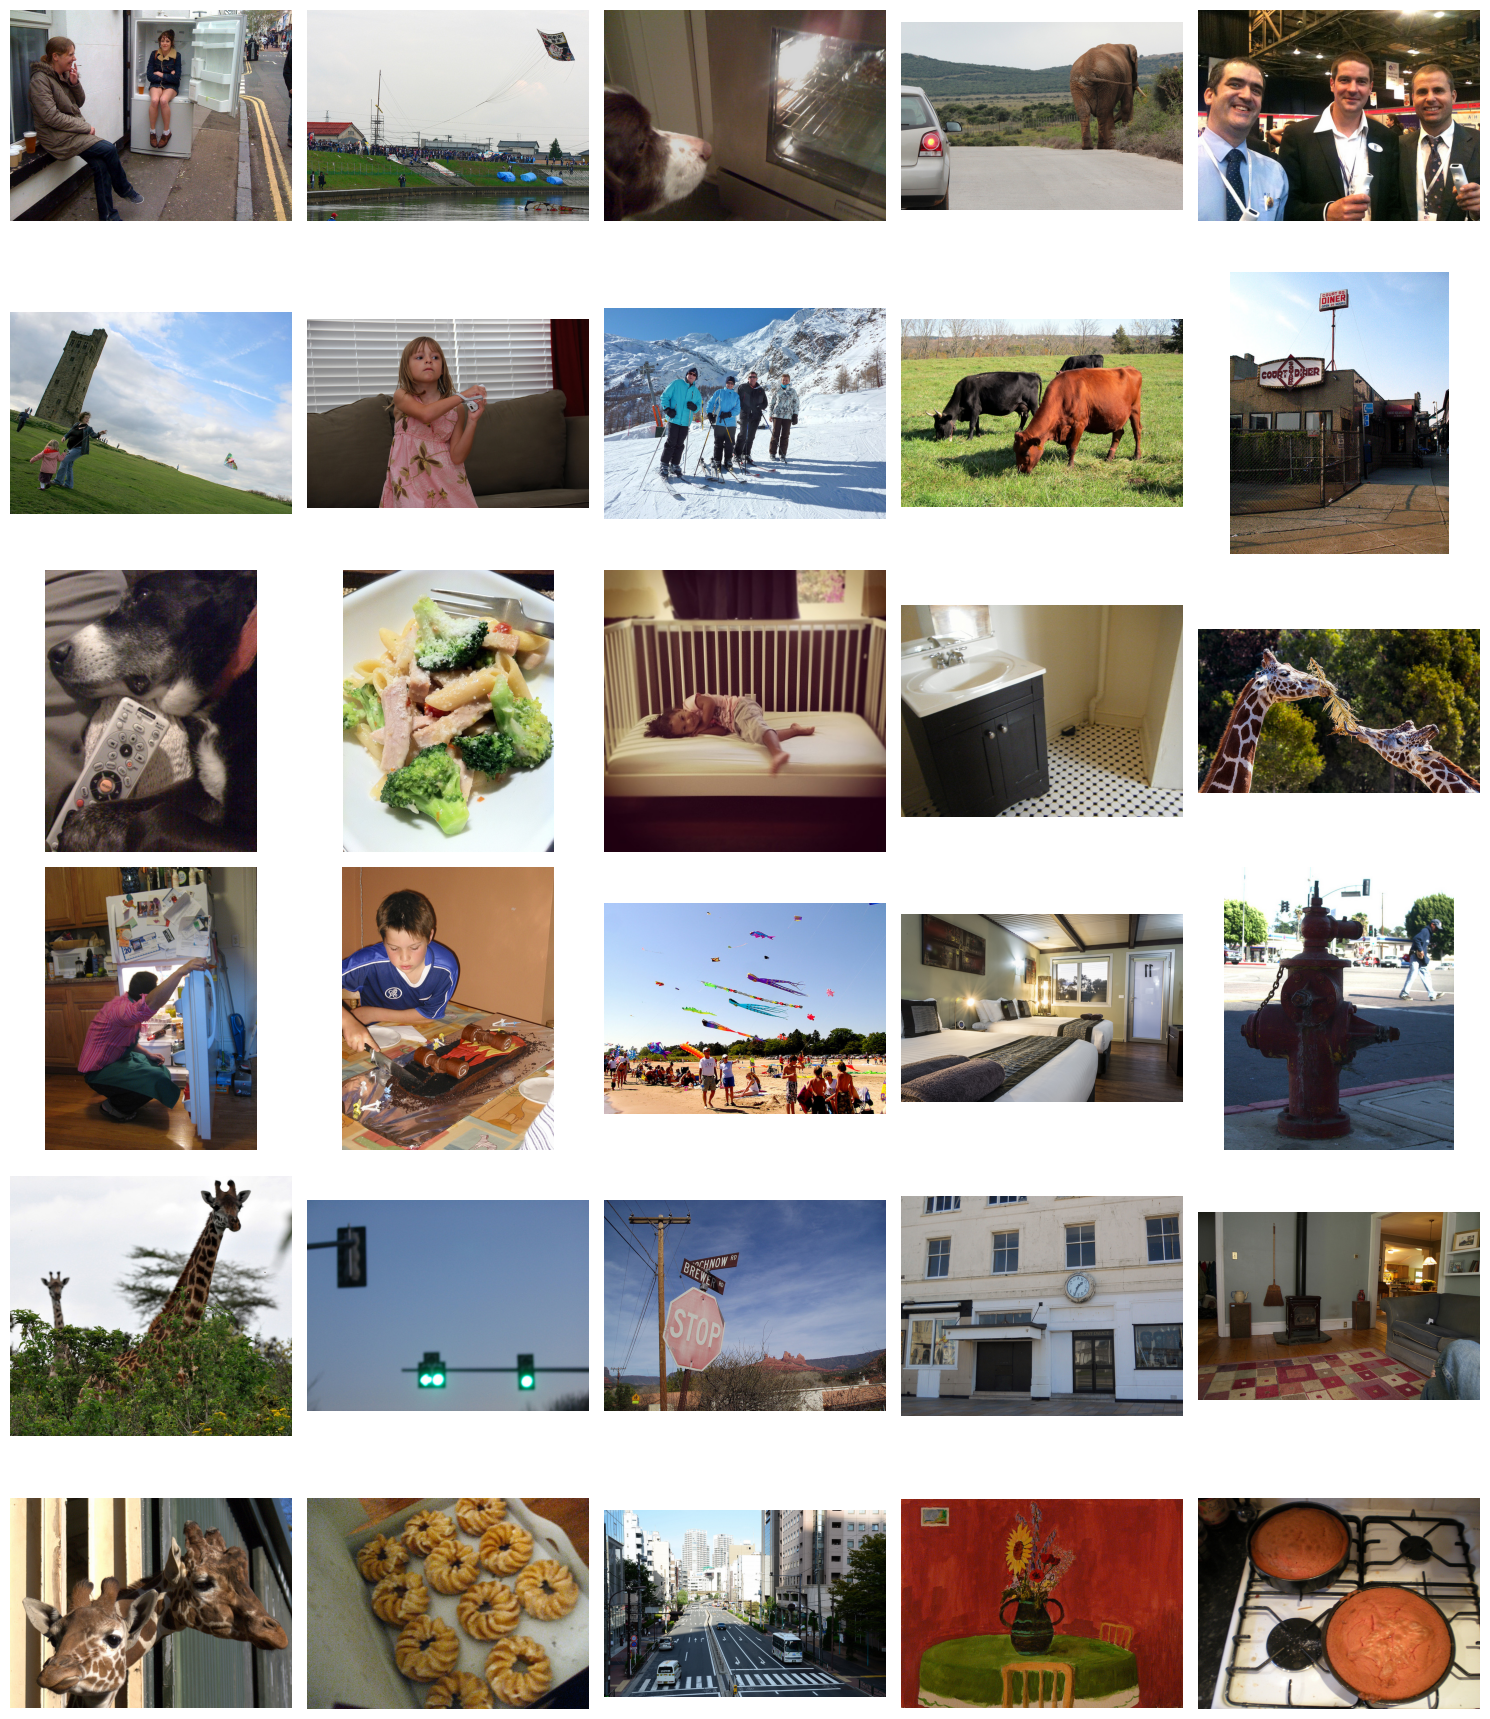

In [27]:
download_dataset('../data/raw/')
plot_images('../data/raw/val2017')